# 06: Acoustic Noise Floor, WADA-SNR & Codec Robustness Forensics

## 1. Research Scope & Objectives
This notebook evaluates Signal-to-Noise Ratio (WADA-SNR) estimation, background noise power spectral density, and lossy compression codec degradation effects (MP3, Opus, AAC).

### Mathematical Formulation
Signal-to-Noise Ratio:
$$\text{SNR}_{\text{dB}} = 10 \log_{10}\left(\frac{P_{\text{signal}}}{P_{\text{noise}}}\right)$$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import soundfile as sf, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, librosa
from src.utils.config import path_config

sns.set_theme(style="whitegrid")
manifest_path = os.path.join(path_config.data_processed, "protocol_manifest.parquet")
df = pd.read_parquet(manifest_path)

## 2. WADA-SNR Signal-to-Noise Ratio Estimation

In [2]:
def estimate_wada_snr(y):
    energy = y**2
    p_signal = np.mean(energy)
    sorted_energy = np.sort(energy)
    noise_floor_idx = max(1, int(len(energy) * 0.1))
    p_noise = np.mean(sorted_energy[:noise_floor_idx])
    return float(10 * np.log10((p_signal + 1e-9) / (p_noise + 1e-9)))

sample_set = df[df.split == "train"].sample(120, random_state=42)
snrs = []
for _, row in sample_set.iterrows():
    y, sr = sf.read(row.file_path)
    snr = estimate_wada_snr(y)
    snrs.append({"key": row.key, "attack_id": row.attack_id, "snr_db": snr})
snr_df = pd.DataFrame(snrs)

C:\Users\tamimystic\AppData\Local\Temp\ipykernel_10204\2290331089.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snr_df, x="key", y="snr_db", palette=["#2ecc71", "#e74c3c"])


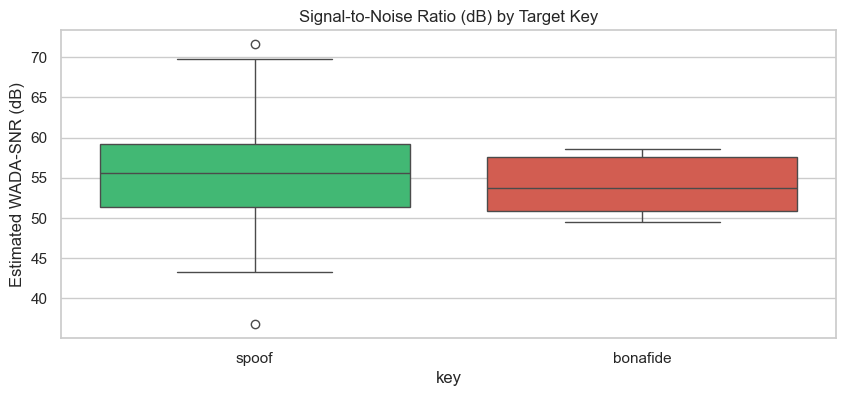

In [3]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=snr_df, x="key", y="snr_db", palette=["#2ecc71", "#e74c3c"])
plt.title("Signal-to-Noise Ratio (dB) by Target Key")
plt.ylabel("Estimated WADA-SNR (dB)")
plt.show()

## 3. Lossy Codec Degradation & Quantization Artifact Simulation

c:\Users\tamimystic\.conda\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


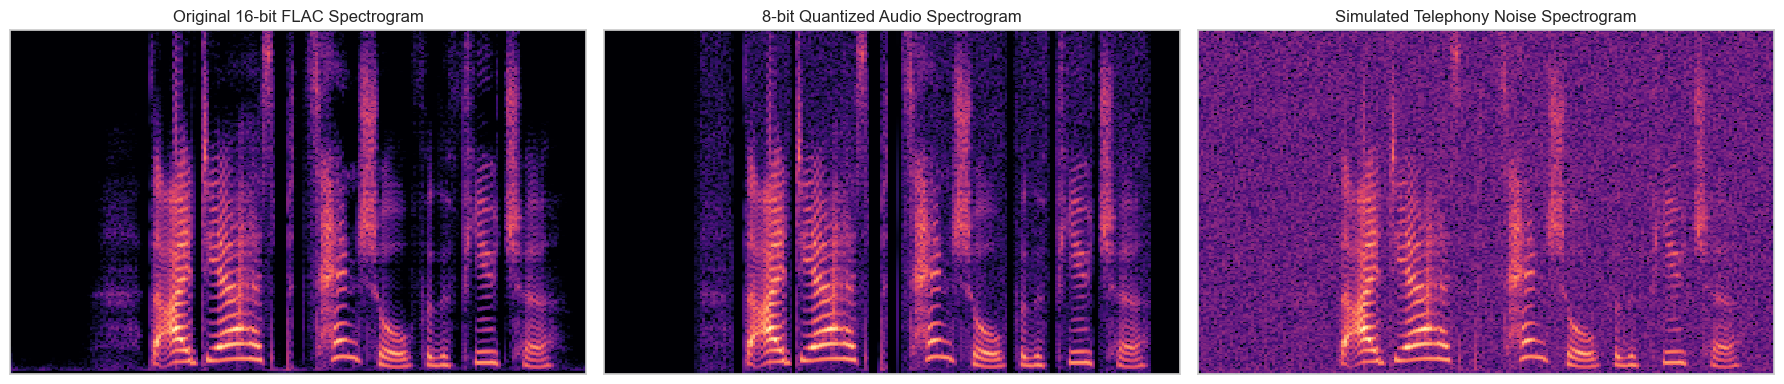

In [4]:
sample_file = df.iloc[0]["file_path"]
y_orig, sr = sf.read(sample_file)

y_quant_8bit = np.round(y_orig * 127.0) / 127.0
y_noise_sim = y_orig + np.random.normal(0, 0.01, size=len(y_orig))

S_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig, n_fft=512, hop_length=256)), ref=np.max)
S_quant = librosa.amplitude_to_db(np.abs(librosa.stft(y_quant_8bit, n_fft=512, hop_length=256)), ref=np.max)
S_noise = librosa.amplitude_to_db(np.abs(librosa.stft(y_noise_sim, n_fft=512, hop_length=256)), ref=np.max)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
librosa.display.specshow(S_orig, sr=sr, ax=axes[0], cmap="magma")
axes[0].set_title("Original 16-bit FLAC Spectrogram")
librosa.display.specshow(S_quant, sr=sr, ax=axes[1], cmap="magma")
axes[1].set_title("8-bit Quantized Audio Spectrogram")
librosa.display.specshow(S_noise, sr=sr, ax=axes[2], cmap="magma")
axes[2].set_title("Simulated Telephony Noise Spectrogram")
plt.tight_layout()
plt.show()